In [1]:
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import scipy.io as sio

In [2]:
# Experiment name for output plots
expt_name = 'LS' 

# List of experiment names
experiment_names = ['LS_OLv8_M36','LS_DAv8_M36']

# insitu_tag plus details of timestep and number of years analysed in matlab file name
insitu_tag = '_SCAN_SM_1d_c1234smv_25yr'
#insitu_tag = '_CalVal_M33_SM_1d__25yr'
#insitu_tag = '_USCRN_SM_1d_c1234smv_25yr'

# Create MATLAB file names based on experiment names
matlab_files = [f'/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/{name}'+ insitu_tag +'_stats.mat' for name in experiment_names]

# Read the first MATLAB file to get the shape of Bias
first_file = matlab_files[0]
mat_contents = sio.loadmat(first_file)
shape = mat_contents['Bias'].shape

# Create empty arrays with the shape of Bias and number of experiments
num_exp = len(matlab_files)
Bias = np.zeros(shape + (num_exp,))
BiasLO = np.zeros(shape + (num_exp,))
BiasUP = np.zeros(shape + (num_exp,))
RMSE = np.zeros(shape + (num_exp,))
RMSELO = np.zeros(shape + (num_exp,))
RMSEUP = np.zeros(shape + (num_exp,))
R = np.zeros(shape + (num_exp,))
RLO = np.zeros(shape + (num_exp,))
RUP = np.zeros(shape + (num_exp,))
absBias = np.zeros(shape + (num_exp,))
absBiasLO = np.zeros(shape + (num_exp,))
absBiasUP = np.zeros(shape + (num_exp,))
anomR = np.zeros(shape + (num_exp,))
anomRLO = np.zeros(shape + (num_exp,))
anomRUP = np.zeros(shape + (num_exp,))
ubRMSE = np.zeros(shape + (num_exp,))
ubRMSELO = np.zeros(shape + (num_exp,))
ubRMSEUP = np.zeros(shape + (num_exp,))

# Read data from the MATLAB files
for i, file in enumerate(matlab_files):
    mat_contents = sio.loadmat(file)
    Bias[:, :, i] = mat_contents['Bias']
    BiasLO[:, :, i] = mat_contents['BiasLO']
    BiasUP[:, :, i] = mat_contents['BiasUP']
    RMSE[:, :, i] = mat_contents['RMSE']
    RMSELO[:, :, i] = mat_contents['RMSELO']
    RMSEUP[:, :, i] = mat_contents['RMSEUP']
    R[:, :, i] = mat_contents['R']
    RLO[:, :, i] = mat_contents['RLO']
    RUP[:, :, i] = mat_contents['RUP']
    absBias[:, :, i] = mat_contents['absBias']
    absBiasLO[:, :, i] = mat_contents['absBiasLO']
    absBiasUP[:, :, i] = mat_contents['absBiasUP']
    anomR[:, :, i] = mat_contents['anomR']
    anomRLO[:, :, i] = mat_contents['anomRLO']
    anomRUP[:, :, i] = mat_contents['anomRUP']
    ubRMSE[:, :, i] = mat_contents['ubRMSE']
    ubRMSELO[:, :, i] = mat_contents['ubRMSELO']
    ubRMSEUP[:, :, i] = mat_contents['ubRMSEUP']

In [3]:
# Get info about ubRMSE
print(ubRMSE.shape)
print(ubRMSE.dtype)

num_sites = ubRMSE.shape[0]
print("num_sites: ", num_sites)

num_depths = ubRMSE.shape[1]
print("num_depths: ", num_depths)

num_expts = ubRMSE.shape[2]
print("num_expts: ", num_expts)

(146, 2, 2)
float64
num_sites:  146
num_depths:  2
num_expts:  2


In [4]:
# Calculate R_mean, Bias, RMSE, and ubRMSE from R
R_mean = np.around(np.nanmean(R, axis=0), decimals=2)
print('R_mean: ', R_mean)
R_std = np.around(np.nanstd(R, axis=0), decimals=3)
num_sites_sr = np.sum(~np.isnan(R), axis=0)
R_CI_LO = np.around(np.nanmean(RLO, axis=0) / np.sqrt(num_sites_sr), decimals=4)
print('R_CI_LO: ', R_CI_LO)
R_CI_UP = np.around(np.nanmean(RUP, axis=0) / np.sqrt(num_sites_sr), decimals=4)
print('R_CI_UP: ', R_CI_UP)
R_CI = np.array([-R_CI_LO, R_CI_UP])
print('R_CI: ', R_CI)
print('R_CI[:, 0, :]: ', R_CI[:, 0, :])

print('R number of site: ', num_sites_sr)
num_sites_r = num_sites_sr

anomR_mean = np.around(np.nanmean(anomR, axis=0), decimals=2)
anomR_std = np.around(np.nanstd(anomR, axis=0), decimals=3)
num_sites_sr = np.sum(~np.isnan(anomR), axis=0)
anomR_CI_LO = np.around(np.nanmean(anomRLO, axis=0) / np.sqrt(num_sites_sr), decimals=4)
anomR_CI_UP = np.around(np.nanmean(anomRUP, axis=0) / np.sqrt(num_sites_sr), decimals=4)
anomR_CI = np.array([-anomR_CI_LO, anomR_CI_UP])
print('anomR_mean: ', anomR_mean)
print('anomR number of site: ', num_sites_sr)
num_sites_anomr = num_sites_sr

Bias_mean = np.around(np.nanmean(Bias, axis=0), decimals=3)
Bias_std = np.around(np.nanstd(Bias, axis=0), decimals=3)
num_sites_sr = np.sum(~np.isnan(Bias), axis=0)
Bias_CI_LO = np.around(np.nanmean(BiasLO, axis=0) / np.sqrt(num_sites_sr), decimals=4)
Bias_CI_UP = np.around(np.nanmean(BiasUP, axis=0) / np.sqrt(num_sites_sr), decimals=4)
Bias_CI = np.array([-Bias_CI_LO, Bias_CI_UP])

absBias_mean = np.around(np.nanmean(absBias, axis=0), decimals=3)
absBias_std = np.around(np.nanstd(absBias, axis=0), decimals=3)
num_sites_sr = np.sum(~np.isnan(absBias), axis=0)
absBias_CI_LO = np.around(np.nanmean(absBiasLO, axis=0) / np.sqrt(num_sites_sr), decimals=4)
absBias_CI_UP = np.around(np.nanmean(absBiasUP, axis=0) / np.sqrt(num_sites_sr), decimals=4)
absBias_CI = np.array([-absBias_CI_LO, absBias_CI_UP])

RMSE_mean = np.around(np.nanmean(RMSE, axis=0), decimals=3)
RMSE_std = np.around(np.nanstd(RMSE, axis=0), decimals=3)
num_sites_sr = np.sum(~np.isnan(RMSE), axis=0)
RMSE_CI_LO = np.around(np.nanmean(RMSELO, axis=0) / np.sqrt(num_sites_sr), decimals=4)
RMSE_CI_UP = np.around(np.nanmean(RMSEUP, axis=0) / np.sqrt(num_sites_sr), decimals=4)
RMSE_CI = np.array([-RMSE_CI_LO, RMSE_CI_UP])

ubRMSE_mean = np.around(np.nanmean(ubRMSE, axis=0), decimals=3)
ubRMSE_std = np.around(np.nanstd(ubRMSE, axis=0), decimals=3)
num_sites_sr = np.sum(~np.isnan(ubRMSE), axis=0)
ubRMSE_CI_LO = np.around(np.nanmean(ubRMSELO, axis=0) / np.sqrt(num_sites_sr), decimals=4)
ubRMSE_CI_UP = np.around(np.nanmean(ubRMSEUP, axis=0) / np.sqrt(num_sites_sr), decimals=4)
ubRMSE_CI = np.array([-ubRMSE_CI_LO, ubRMSE_CI_UP])

print('ubRMSE_mean: ', ubRMSE_mean)
print('ubRMSE number of sites: ', num_sites_sr)
num_sites_ubrmse = num_sites_sr

R_mean:  [[0.62 0.65]
 [0.64 0.66]]
R_CI_LO:  [[-0.0069 -0.0064]
 [-0.0181 -0.0172]]
R_CI_UP:  [[0.0058 0.0054]
 [0.0121 0.0115]]
R_CI:  [[[0.0069 0.0064]
  [0.0181 0.0172]]

 [[0.0058 0.0054]
  [0.0121 0.0115]]]
R_CI[:, 0, :]:  [[0.0069 0.0064]
 [0.0058 0.0054]]
R number of site:  [[141 141]
 [116 116]]
anomR_mean:  [[0.54 0.58]
 [0.55 0.58]]
anomR number of site:  [[140 140]
 [114 114]]
ubRMSE_mean:  [[0.057 0.056]
 [0.039 0.038]]
ubRMSE number of sites:  [[141 141]
 [116 116]]


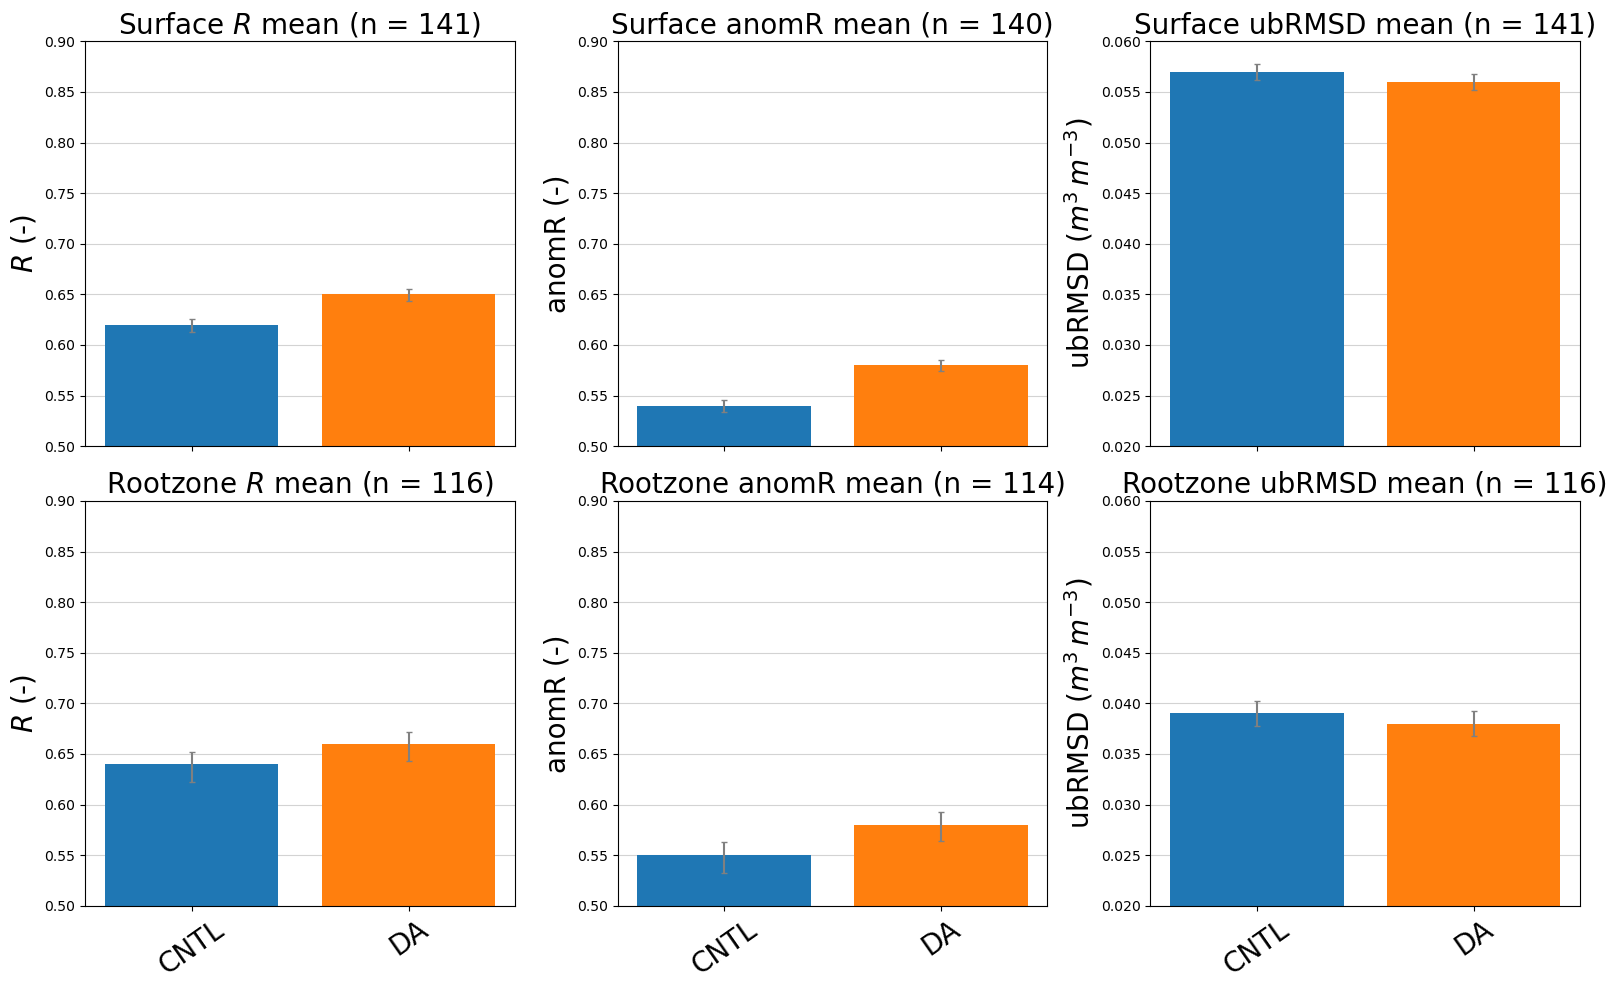

In [5]:
expt_labels = ["CNTL", "DA"]

ind = np.arange(num_expts)

title_fontsize = 20
label_fontsize = 20
y_tick_label_fontsize = 18

# Create a figure with a 2x3 subplot grid
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

# Subplot 1: Surface R_mean
axs[0, 0].bar(ind, R_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 0].errorbar(ind, R_mean[0, :num_expts], yerr=R_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
# axs[0, 0].set_xlabel('Experiments')
axs[0, 0].set_ylabel(r'$R$ (-)', fontsize=label_fontsize)
axs[0, 0].set_ylim(0.5, 0.9)
#axs[0, 0].set_yticks(np.arange(0.5, 0.7, 0.05))
#axs[0, 0].set_yticklabels([0.5, 0.55, 0.6, 0.65], fontsize=y_tick_label_fontsize)
axs[0, 0].set_axisbelow(True)
axs[0, 0].grid(axis='y', color='lightgrey')
axs[0, 0].set_title(r'Surface $R$ mean (n = {})'.format(num_sites_r[0, 0]), fontsize=title_fontsize)
axs[0, 0].set_xticks(ind)
#axs[0, 0].set_xticklabels(expt_labels[:num_expts], rotation=25, fontsize=14)
axs[0, 0].set_xticklabels('', fontsize=1)

# Subplot 2: anomR_mean
axs[0, 1].bar(ind, anomR_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 1].errorbar(ind, anomR_mean[0, :num_expts], yerr=anomR_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
#axs[0, 1].set_xlabel('Experiments')
axs[0, 1].set_ylabel('anomR (-)', fontsize=label_fontsize)
axs[0, 1].set_ylim(0.5, 0.9)
#axs[0, 1].set_yticks(np.arange(0.5, 0.7, 0.05))
#axs[0, 1].set_yticklabels([0.5, 0.55, 0.6, 0.65], fontsize=y_tick_label_fontsize)
axs[0, 1].set_axisbelow(True)
axs[0, 1].grid(axis='y', color='lightgrey')
axs[0, 1].set_title(r'Surface anomR mean (n = {})'.format(num_sites_anomr[0, 0]), fontsize=title_fontsize)
axs[0, 1].set_xticks(ind)
# axs[0, 1].set_xticklabels(expt_labels[:num_expts], rotation=25, fontsize=14)
axs[0, 1].set_xticklabels('', fontsize=1)

# Subplot 3: Surface ubRMSE_mean
axs[0, 2].bar(ind, ubRMSE_mean[0, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[0, 2].errorbar(ind, ubRMSE_mean[0, :num_expts], yerr=ubRMSE_CI[:, 0, :num_expts], fmt='none', ecolor='grey', capsize=2)
# axs[0, 1].set_xlabel('Experiments')
axs[0, 2].set_ylabel('ubRMSD ($m^3 \, m^{-3}$)', fontsize=label_fontsize)
axs[0, 2].set_ylim(0.02, 0.06)
#axs[0, 2].set_yticks(np.arange(0.03, 0.06, 0.005))
#axs[0, 2].set_yticklabels([0.03, ' ', 0.04, ' ', 0.05, ' '], fontsize=y_tick_label_fontsize)
axs[0, 2].set_axisbelow(True)
axs[0, 2].grid(axis='y', color='lightgrey')
axs[0, 2].set_title(r'Surface ubRMSD mean (n = {})'.format(num_sites_ubrmse[0, 0]), fontsize=title_fontsize)
axs[0, 2].set_xticks(ind)
# axs[0, 2].set_xticklabels(expt_labels[:num_expts], rotation=25, fontsize=14)
axs[0, 2].set_xticklabels('', fontsize=1)

# Subplot 4: Root zone R_mean
axs[1, 0].bar(ind, R_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 0].errorbar(ind, R_mean[1, :num_expts], yerr=R_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
#axs[1, 0].set_xlabel('Experiments', fontsize=14)
axs[1, 0].set_ylabel(r'$R$ (-)', fontsize=label_fontsize)
axs[1, 0].set_ylim(0.5, 0.9)
#axs[1, 0].set_yticks(np.arange(0.5, 0.7, 0.05))
#axs[1, 0].set_yticklabels([0.5, 0.55, 0.6, 0.65], fontsize=y_tick_label_fontsize)
axs[1, 0].set_axisbelow(True)
axs[1, 0].grid(axis='y', color='lightgrey')
axs[1, 0].set_title(r'Rootzone $R$ mean (n = {})'.format(num_sites_r[1, 0]), fontsize=title_fontsize)
axs[1, 0].set_xticks(ind)
axs[1, 0].set_xticklabels(expt_labels[:num_expts], rotation=35, fontsize=label_fontsize)

# Subplot 5: anomR_mean
axs[1, 1].bar(ind, anomR_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 1].errorbar(ind, anomR_mean[1, :num_expts], yerr=anomR_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
#axs[1, 1].set_xlabel('Experiments', fontsize=14)
axs[1, 1].set_ylabel('anomR (-)', fontsize=label_fontsize)
axs[1, 1].set_ylim(0.5, 0.9)
#axs[1, 1].set_yticks(np.arange(0.5, 0.7, 0.05))
#axs[1, 1].set_yticklabels([0.5, 0.55, 0.6, 0.65], fontsize=y_tick_label_fontsize)
axs[1, 1].set_axisbelow(True)
axs[1, 1].grid(axis='y', color='lightgrey')
axs[1, 1].set_title(r'Rootzone anomR mean (n = {})'.format(num_sites_anomr[1, 0]), fontsize=title_fontsize)
axs[1, 1].set_xticks(ind)
axs[1, 1].set_xticklabels(expt_labels[:num_expts], rotation=35, fontsize=label_fontsize)

# Subplot 6: Root zone ubRMSE_mean
axs[1, 2].bar(ind, ubRMSE_mean[1, :num_expts], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][:num_expts])
axs[1, 2].errorbar(ind, ubRMSE_mean[1, :num_expts], yerr=ubRMSE_CI[:, 1, :num_expts], fmt='none', ecolor='grey', capsize=2)
#axs[1, 2].set_xlabel('Experiments', fontsize=14)
axs[1, 2].set_ylabel('ubRMSD ($m^3 \, m^{-3}$)', fontsize=label_fontsize)
axs[1, 2].set_ylim(0.02, 0.06)
#axs[1, 2].set_yticks(np.arange(0.03, 0.06, 0.005))
#axs[1, 2].set_yticklabels([0.03, ' ', 0.04, ' ', 0.05, ' '], fontsize=y_tick_label_fontsize)
axs[1, 2].set_axisbelow(True)
axs[1, 2].grid(axis='y', color='lightgrey')
axs[1, 2].set_title(r'Rootzone ubRMSD mean (n = {})'.format(num_sites_ubrmse[1, 0]), fontsize=title_fontsize)
axs[1, 2].set_xticks(ind)
axs[1, 2].set_xticklabels(expt_labels[:num_expts], rotation=35, fontsize=label_fontsize)

plt.tight_layout()

plt.savefig(expt_name + '_surf_rz_stats.png')

plt.show()

In [6]:
m_rs_file = '/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36' + insitu_tag + '_raw_timeseries.mat'
mat_contents = sio.loadmat(m_rs_file)

# List of variables and their dimensions in the MATLAB file
print(sio.whosmat(m_rs_file))

vars = [k for k in mat_contents.keys() if not k.startswith('__')]
print('Variables in MAT file:')
for name in vars:
    val = mat_contents[name]
    shp = getattr(val, 'shape', None)
    print(f"{name}: type={type(val).__name__}, shape={shp}")

# ...existing code...


[('INSITU_id', (1, 146), 'cell'), ('INSITU_id_string', (1,), 'char'), ('INSITU_lat', (146, 1), 'double'), ('INSITU_lon', (146, 1), 'double'), ('INSITU_path', (1,), 'char'), ('INSITU_sm', (8766, 2, 146), 'double'), ('INSITU_st', (8766, 5, 146), 'double'), ('INSITU_tag', (1,), 'char'), ('LDAS_prcp_org', (8766, 1, 146), 'double'), ('LDAS_sm_org', (8766, 2, 146), 'double'), ('LDAS_st_org', (8766, 2, 146), 'double'), ('Nmin', (1, 1), 'double'), ('add_anomR', (1, 1), 'double'), ('data_ext', (1,), 'char'), ('date_time', (1, 1), 'struct'), ('date_time_string', (1,), 'char'), ('date_time_vec', (1, 8766), 'struct'), ('date_time_vec1', (1, 1), 'struct'), ('distance', (112573, 1), 'double'), ('distance_min', (1, 146), 'double'), ('domain', (1,), 'char'), ('dtstep', (1, 1), 'double'), ('end_time', (1, 1), 'struct'), ('exp_path', (1,), 'char'), ('exp_run', (1,), 'char'), ('exp_run_name', (2, 1), 'cell'), ('file_ext', (1,), 'char'), ('file_tag', (1,), 'char'), ('fname', (1,), 'char'), ('fname_tilecoo

In [7]:
# Extract INSITU_lat from the MATLAB file
INSITU_lat = mat_contents['INSITU_lat']

# Determine the number of sites below 40 degrees N
num_sites_below_40N = np.sum(INSITU_lat < 60)
print(f"Number of sites below 40 degrees N: {num_sites_below_40N}")

Number of sites below 40 degrees N: 146


In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract latitude and longitude of the stations
INSITU_lat = mat_contents['INSITU_lat'].flatten()
INSITU_lon = mat_contents['INSITU_lon'].flatten()

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_3023/1237866360.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)  # Discrete colormap


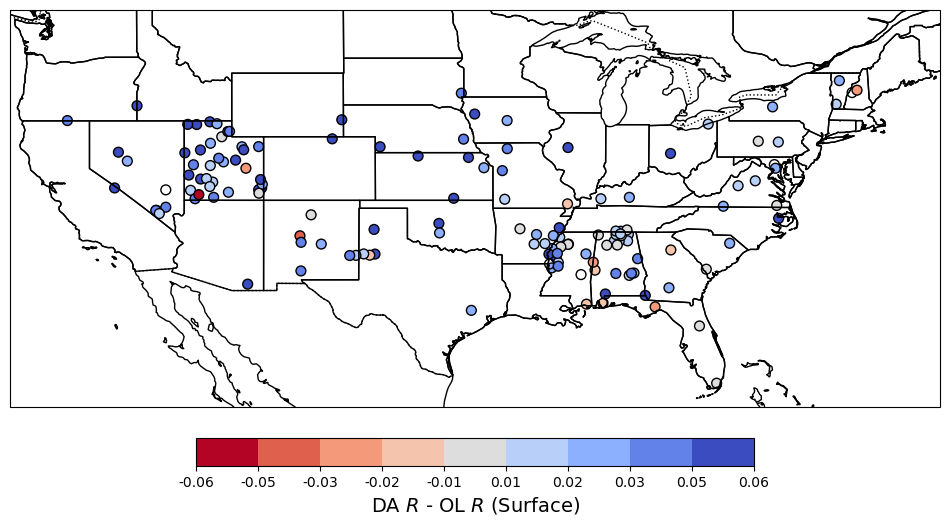

In [9]:
# Calculate the difference between DA R and OL R for each site
R_diff = R[:, :, 1] - R[:, :, 0]

# Define discrete color levels
levels = np.linspace(-0.06, 0.06, 10)
cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)  # Discrete colormap


# Create a map
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='black')  # Add state boundaries

# Set extent to show all of CONUS
ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

# Plot the station locations with color representing the R difference
# Use surface layer (depth index 0). Avoid using undefined variable `i`.
sc = ax.scatter(INSITU_lon, INSITU_lat, c=R_diff[:, 0], cmap=cmap, s=50, edgecolor='k',
                transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

# Add a colorbar (use plt.colorbar with the scatter mappable)
cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label(r'DA $\mathit{R}$ - OL $\mathit{R}$ (Surface)', fontsize=14)
cbar.set_ticks(levels)
cbar.ax.set_xticklabels([f"{lvl:.2f}" for lvl in levels])

# Add labels and title
# ax.set_title(r'DA $\mathit{R}$ - OL $\mathit{R}$ (Surface)', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Show the map
plt.show()

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_3023/1802616468.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)


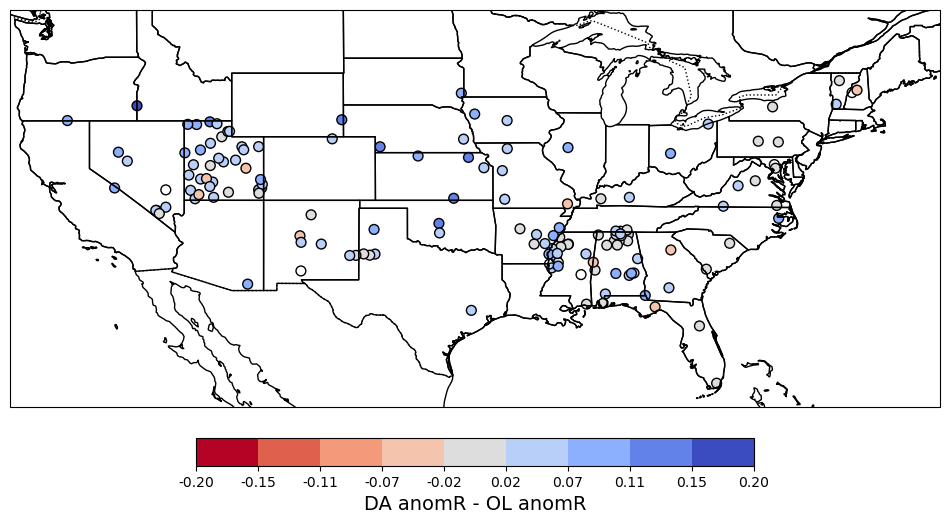

In [10]:
# Plot DA - OL for anomR (surface)
anomR_diff = anomR[:, :, 1] - anomR[:, :, 0]
surf_diff = anomR_diff[:, 0]

# Create symmetric discrete levels around zero based on data range
maxabs = np.nanmax(np.abs(surf_diff))
if np.isnan(maxabs) or maxabs == 0:
    levels = np.linspace(-0.01, 0.01, 10)
else:
    levels = np.linspace(-maxabs, maxabs, 10)
cmap = plt.cm.get_cmap('coolwarm_r', len(levels) - 1)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='black')

ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

sc = ax.scatter(INSITU_lon, INSITU_lat, c=surf_diff, cmap=cmap, s=50, edgecolor='k',
                transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('DA anomR - OL anomR', fontsize=14)
cbar.set_ticks(levels)
cbar.ax.set_xticklabels([f"{lvl:.2f}" for lvl in levels])

#ax.set_title(f'{insitu_tag} DA anomR - OL anomR (Surface)', fontsize=title_fontsize)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()

/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_3023/537356336.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('coolwarm', len(levels) - 1)


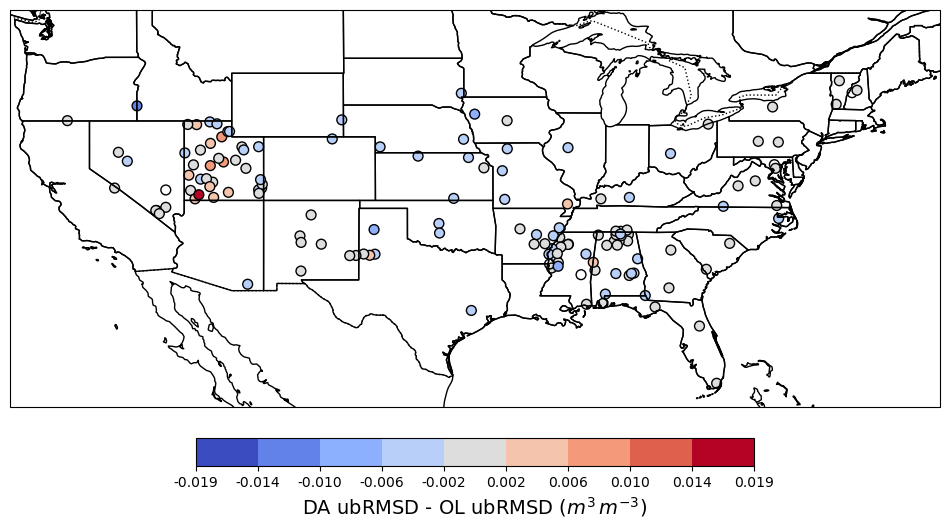

In [11]:
# Map of DA - OL for ubRMSE (surface), using a reversed colormap
ubRMSE_diff = ubRMSE[:, :, 1] - ubRMSE[:, :, 0]
surf_diff = ubRMSE_diff[:, 0]

# Create symmetric discrete levels around zero based on data range
maxabs = np.nanmax(np.abs(surf_diff))
if np.isnan(maxabs) or maxabs == 0:
    levels = np.linspace(-0.01, 0.01, 10)
else:
    levels = np.linspace(-maxabs, maxabs, 10)

# Use a reversed colormap
cmap = plt.cm.get_cmap('coolwarm', len(levels) - 1)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, edgecolor='black')

ax.set_extent([-125, -66.5, 24, 49], crs=ccrs.PlateCarree())

sc = ax.scatter(INSITU_lon, INSITU_lat, c=surf_diff, cmap=cmap, s=50, edgecolor='k',
                transform=ccrs.PlateCarree(), vmin=levels[0], vmax=levels[-1])

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('DA ubRMSD - OL ubRMSD ($m^3\\,m^{-3}$)', fontsize=14)
cbar.set_ticks(levels)
cbar.ax.set_xticklabels([f"{lvl:.3f}" for lvl in levels])

#ax.set_title(f'{insitu_tag} DA ubRMSD - OL ubRMSD (Surface)', fontsize=title_fontsize)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

plt.show()